# 11 — MFIV robustness: bounding the ATM-proxy bias (Week 5, step 2b)

We build $\rho_{\text{implied}}$ from **ATM** ($\pm50\Delta$) IVs, while DMV use the **model-free
implied variance** (MFIV, the whole smile). The index smile is steep, so ATM understates index
variance more than component variance ⇒ $\rho_{\text{implied}}$ is **understated (conservative)**.
Here we reconstruct MFIV on the **index leg** (Carr–Madan / VIX-style replication from the full
SPX delta grid) and **quantify the bias** on $\rho_{\text{implied}}$: how much would it rise?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from dispersion.data.wrds_client import get_connection

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"
weights = pd.read_parquet(P / "weights.parquet"); weights["rebalance_date"] = pd.to_datetime(weights["rebalance_date"])
rebals = sorted(weights["rebalance_date"].unique())

db = get_connection()
# full SPX smile (all deltas), 91d, at every rebalance date; + short zero rate
parts = []
for y in range(1996, 2025):
    ds = [str(pd.Timestamp(r).date()) for r in rebals if pd.Timestamp(r).year == y]
    if not ds:
        continue
    q = f"""SELECT date, delta, cp_flag, impl_strike AS k, impl_volatility AS iv, impl_premium AS prem
            FROM optionm.vsurfd{y}
            WHERE secid=108105 AND days=91 AND date IN ({','.join(chr(39)+d+chr(39) for d in ds)})
              AND impl_premium IS NOT NULL AND impl_strike IS NOT NULL"""
    parts.append(db.raw_sql(q))
smile = pd.concat(parts, ignore_index=True)
smile["date"] = pd.to_datetime(smile["date"])
rates = pd.read_parquet(P / "rates.parquet"); rates["date"] = pd.to_datetime(rates["date"])
db.close()
print(f"smile rows {len(smile)} | dates {smile['date'].nunique()} | pillars/date ~{len(smile)//smile['date'].nunique()}")

Loading library list...


Done


smile rows 3944 | dates 116 | pillars/date ~34


In [2]:
T = 91 / 365.0
def rate_at(d):
    r = rates[rates["date"] == d]
    if r.empty:
        r = rates[rates["date"] <= d].tail(1)
    return float(np.interp(91, r["days"], r["rate"])) / 100

def mfiv_one(g, r):
    g = g.dropna(subset=["k", "prem"]).copy()
    # ATM-forward proxy: strike at the +50-delta call (≈ ATM-forward)
    atm = g[(g["cp_flag"] == "C") & (g["delta"] == 50)]
    if atm.empty:
        return np.nan, np.nan
    F = float(atm["k"].iloc[0])
    sig_atm = 0.5 * (g[(g.cp_flag=='C')&(g.delta==50)]["iv"].iloc[0] + g[(g.cp_flag=='P')&(g.delta==-50)]["iv"].iloc[0])
    # OTM strip: puts below F, calls at/above F
    otm = g[((g.cp_flag=='P') & (g.k < F)) | ((g.cp_flag=='C') & (g.k >= F))].sort_values("k").reset_index(drop=True)
    if len(otm) < 6:
        return np.nan, sig_atm
    K = otm["k"].to_numpy(); Q = otm["prem"].to_numpy()
    dK = np.gradient(K)
    var = (2 * np.exp(r * T) / T) * np.sum(dK / K**2 * Q)
    K0 = K[K <= F].max() if (K <= F).any() else K[0]
    var -= (1.0 / T) * (F / K0 - 1.0)**2
    return (np.sqrt(var) if var > 0 else np.nan), sig_atm

rows = []
for d, g in smile.groupby("date"):
    mf, at = mfiv_one(g, rate_at(d))
    rows.append((d, at, mf))
iv_cmp = pd.DataFrame(rows, columns=["date", "sig_atm", "sig_mfiv"]).dropna()
iv_cmp["skew_prem"] = iv_cmp["sig_mfiv"] - iv_cmp["sig_atm"]
print(f"index MFIV vs ATM ({len(iv_cmp)} rebalances):")
print(f"  sig_atm mean {iv_cmp['sig_atm'].mean():.4f} | sig_mfiv mean {iv_cmp['sig_mfiv'].mean():.4f}")
print(f"  skew premium (MFIV - ATM): mean {iv_cmp['skew_prem'].mean():+.4f} | median {iv_cmp['skew_prem'].median():+.4f} | in [{iv_cmp['skew_prem'].min():+.4f}, {iv_cmp['skew_prem'].max():+.4f}]")

index MFIV vs ATM (116 rebalances):
  sig_atm mean 0.1845 | sig_mfiv mean 0.1968
  skew premium (MFIV - ATM): mean +0.0123 | median +0.0123 | in [+0.0013, +0.0325]


In [3]:
# Propagate to rho_implied: rho = (sig_I^2 - S2)/(S1^2 - S2). Substituting sig_MFIV for
# sig_ATM on the INDEX raises the numerator -> Drho = (sig_MFIV^2 - sig_ATM^2)/(S1^2 - S2).
# Reconstruct the denominator (S1^2 - S2) from components + weights at each rebalance.
ivc = pd.read_parquet(P / "iv_components.parquet"); ivc["date"] = pd.to_datetime(ivc["date"])
sig = pd.read_parquet(P / "signal.parquet"); sig["date"] = pd.to_datetime(sig["date"])

den_rows = []
for reb in rebals:
    reb = pd.Timestamp(reb)
    day = ivc[(ivc["rebalance_date"] == reb) & (ivc["date"] == reb)].dropna(subset=["iv_atm"])
    w = weights[weights["rebalance_date"] == reb].set_index("permno")["weight"]
    m = day.set_index("permno")
    common = m.index.intersection(w.index)
    if len(common) < 60:
        continue
    wv = (w.loc[common] / w.loc[common].sum()).to_numpy()
    sv = m.loc[common, "iv_atm"].to_numpy()
    S1 = float((wv * sv).sum()); S2 = float((wv**2 * sv**2).sum())
    den_rows.append((reb, S1**2 - S2))
den = pd.DataFrame(den_rows, columns=["date", "denom"])

b = iv_cmp.merge(den, on="date").merge(sig[["date", "rho_implied"]], on="date")
b["d_rho"] = (b["sig_mfiv"]**2 - b["sig_atm"]**2) / b["denom"]
b["rho_mfiv"] = b["rho_implied"] + b["d_rho"]
print(f"rho_implied bias from the ATM proxy (index leg), {len(b)} rebalances:")
print(f"  Drho (rho_MFIV - rho_ATM): mean {b['d_rho'].mean():+.4f} | median {b['d_rho'].median():+.4f} | in [{b['d_rho'].min():+.4f}, {b['d_rho'].max():+.4f}]")
print(f"  rho_ATM mean {b['rho_implied'].mean():.4f} -> rho_MFIV mean {b['rho_mfiv'].mean():.4f}")
print(f"  sign: Drho > 0 on {100*(b['d_rho']>0).mean():.0f}% of dates (bias is conservative = rho understated)")
b[["date", "sig_atm", "sig_mfiv", "rho_implied", "rho_mfiv", "d_rho"]].to_csv(ROOT/"results"/"tables"/"table_mfiv_bias.csv", index=False)

rho_implied bias from the ATM proxy (index leg), 116 rebalances:
  Drho (rho_MFIV - rho_ATM): mean +0.0655 | median +0.0682 | in [+0.0048, +0.1486]
  rho_ATM mean 0.4307 -> rho_MFIV mean 0.4962
  sign: Drho > 0 on 100% of dates (bias is conservative = rho understated)


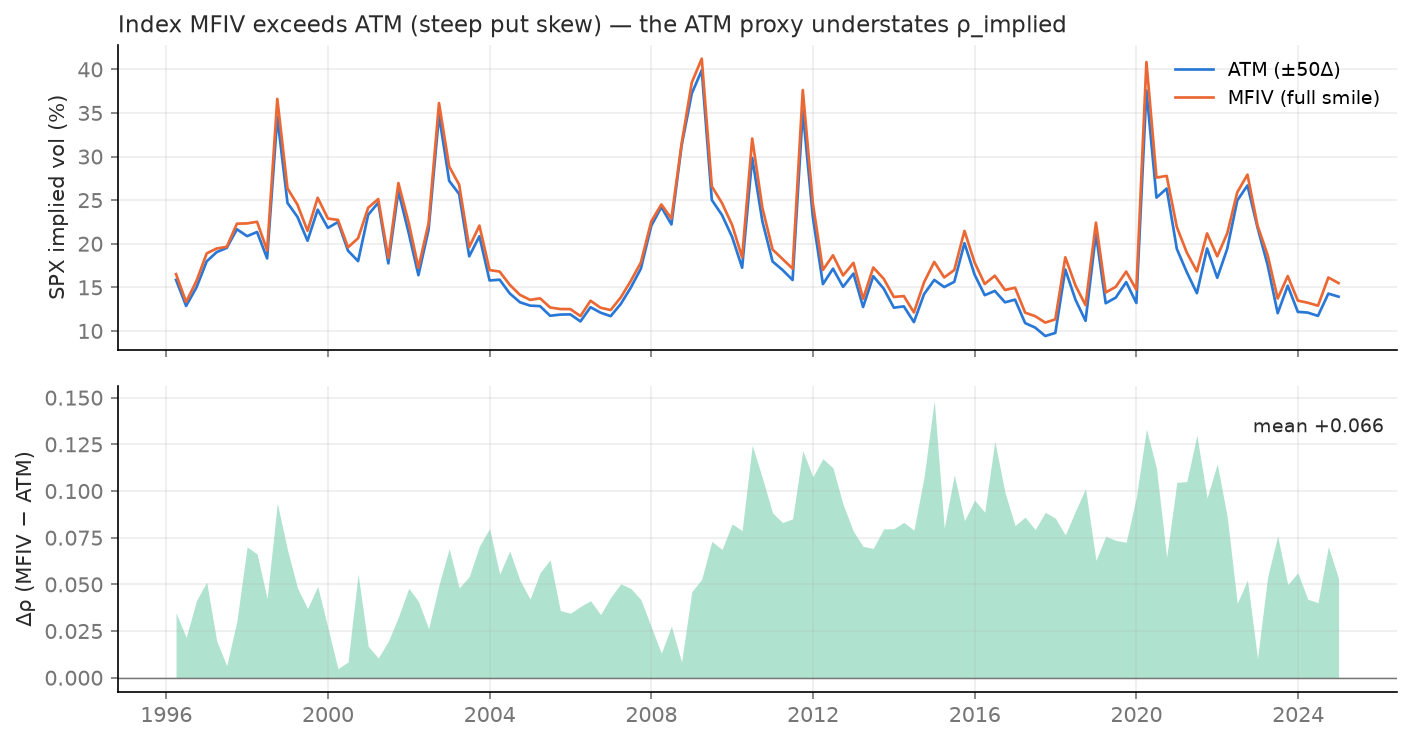

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.22, "figure.dpi": 150})
INK, MUTED = "#2b2b2b", "#767676"
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw={"hspace": 0.12})
a1.plot(b["date"], b["sig_atm"]*100, color="#2a78d6", lw=1.3, label="ATM (±50Δ)")
a1.plot(b["date"], b["sig_mfiv"]*100, color="#eb6834", lw=1.3, label="MFIV (full smile)")
a1.set_ylabel("SPX implied vol (%)", color=INK); a1.legend(frameon=False, fontsize=9)
a1.set_title("Index MFIV exceeds ATM (steep put skew) — the ATM proxy understates ρ_implied", loc="left", fontsize=11, color=INK)
a2.axhline(0, color=MUTED, lw=0.7)
a2.fill_between(b["date"], 0, b["d_rho"], color="#1baf7a", alpha=0.35, lw=0)
a2.set_ylabel("Δρ (MFIV − ATM)", color=INK); a2.set_xlabel("")
a2.annotate(f"mean +{b['d_rho'].mean():.3f}", xy=(0.99, 0.85), xycoords="axes fraction", ha="right", fontsize=9, color=INK)
for a in (a1, a2): a.tick_params(colors=MUTED)
a2.xaxis.set_major_locator(mdates.YearLocator(4))
fig.savefig(ROOT/"results"/"figures"/"fig_mfiv_bias.png", bbox_inches="tight"); plt.show()

## Reading

- MFIV > ATM for the index (steep put skew) ⇒ the ATM proxy understates $\rho_{\text{implied}}$.
- The bias $\Delta\rho$ is a **conservative** shift (positive): our headline premium is a lower bound.
- Magnitude bounds the ATM-proxy limitation quantitatively for the thesis (README §5).